# Actividad 5.2 — Regresión Lineal Simple
## Base de datos: Análisis de Piso (GAC)

### Paso 1: Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

### Paso 2: Cargar datos
En Colab, sustituye la línea `files.upload()` si es necesario; aquí se asume que el CSV ya está en la misma carpeta.

In [2]:
# from google.colab import files
# files.upload()

data = pd.read_csv('analisis_piso_sin_nulos.csv')
data.head()

,Asesor,Leads_2024_feb,Leads_2024_mar,Leads_2024_abr,Leads_2024_may,Leads_2024_jun,Leads_2024_jul,Leads_2024_ago,Leads_2024_sep,Leads_2024_oct,...,Raking_Ventas,Dependencia_de_Piso,Historico_PDM,Historico_SDC,Conversion_PDM,Conversion_SDC,Factor_PDM,Factor_SDC,Raking_PDM,Raking_SDC
0,ABIGAIL,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23,0.00,1,5.0,1.00,0.00,1.00,5.00,1.0,20.0
1,ALAN GONZALES,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6,0.61,59,40.0,0.31,0.02,3.28,2.22,7.0,10.0
2,ALICIA LEDESMA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0.00,1,1.0,0.00,0.00,0.00,0.00,0.0,0.0
3,AURELIO FELIPE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,...,11,0.38,28,31.0,0.29,0.01,3.50,3.88,9.0,18.0
4,CARLOS ALBERTO NIETO,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,...,8,0.60,64,30.0,0.23,0.02,4.27,2.00,13.0,7.0


### Paso 3: Nulos y tipos numéricos
`Raking_Ventas` trae el texto `"-"` en algunas filas; se convierte a numérico y esas filas quedan como NaN.

In [3]:
data['Raking_Ventas'] = pd.to_numeric(data['Raking_Ventas'], errors='coerce')
print(data.isnull().sum())

cualitativas = data[['Asesor']]
cuantitativas = data.drop(columns=['Asesor'])

Asesor                      0
Leads_2024_feb              0
Leads_2024_mar              0
Leads_2024_abr              0
Leads_2024_may              0
Leads_2024_jun              0
Leads_2024_jul              0
Leads_2024_ago              0
Leads_2024_sep              0
Leads_2024_oct              0
Leads_2024_nov              0
Leads_2024_dic              0
Leads_2025_ene              0
Leads_2025_feb              0
Leads_2025_mar              0
Leads_2025_abr              0
Total_Leads                 0
Total_Leads_Ajustado        0
Raking_Leads                0
Raking_Leads_Ajustado       0
Ventas_2024_feb             0
Ventas_2024_mar             0
Ventas_2024_abr             0
Ventas_2024_may             0
Ventas_2024_jun             0
Ventas_2024_jul             0
Ventas_2024_ago             0
Ventas_2024_sep             0
Ventas_2024_oct             0
Ventas_2024_nov             0
Ventas_2024_dic             0
Ventas_2025_ene             0
Ventas_2025_feb             0
Ventas_202

### Paso 4: Outliers (método de desviación estándar)
Valores fuera de ±3 desviaciones estándar se marcan como NaN y se imputan con la media de su columna.

In [4]:
lim_sup = cuantitativas.mean() + 3*cuantitativas.std()
lim_inf = cuantitativas.mean() - 3*cuantitativas.std()
data_clean = cuantitativas[(cuantitativas <= lim_sup) & (cuantitativas >= lim_inf)]
data_clean = data_clean.fillna(round(data_clean.mean(), 1))
print('Nulos restantes:', data_clean.isnull().sum().sum())

Nulos restantes: 0


### Paso 5: Matriz de correlación

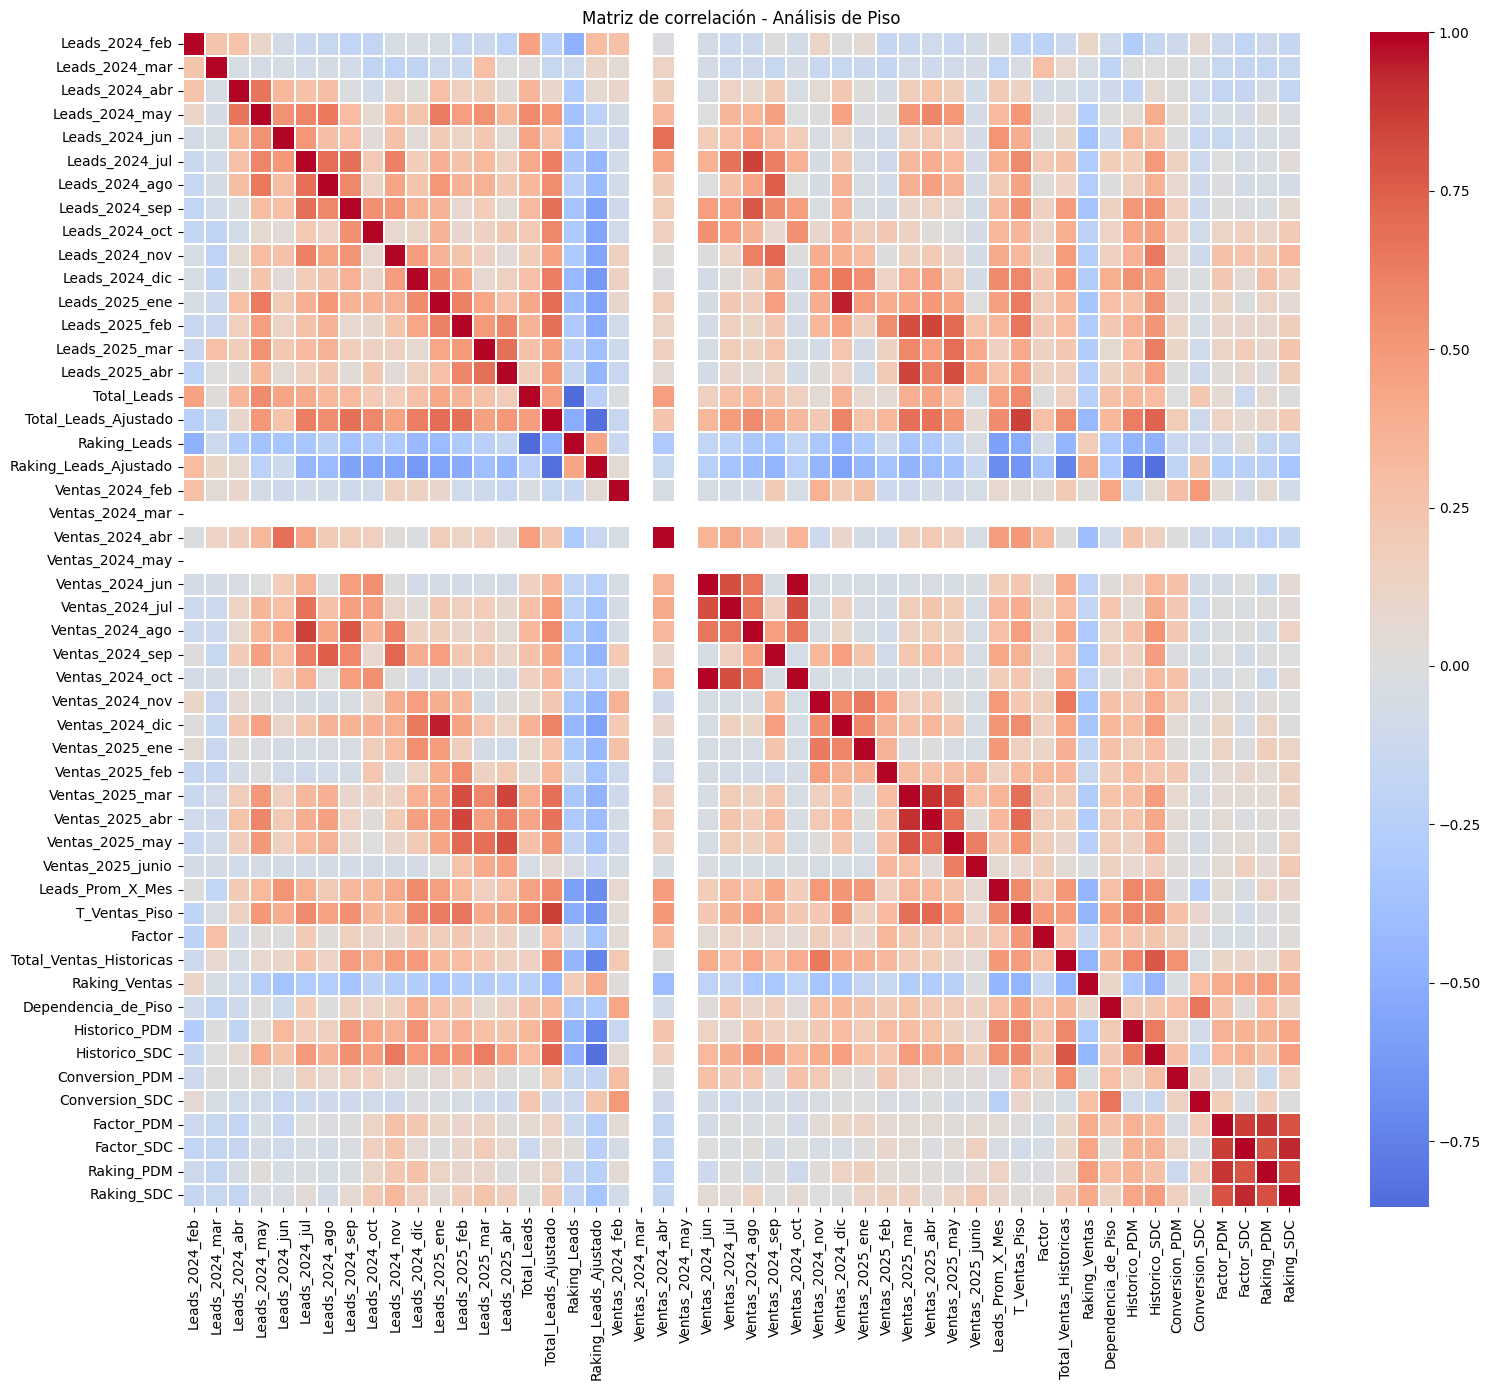

In [5]:
corr = data_clean.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Matriz de correlación - Análisis de Piso')
plt.tight_layout()
plt.savefig('heatmap_piso.png', dpi=150)
plt.show()

### Paso 6: Pares de variables más correlacionadas
Se descartan la diagonal y los duplicados (cada par aparece una sola vez).

In [6]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(10)
print(top_pairs)

Ventas_2024_jun       Ventas_2024_oct    1.000000
Leads_2025_ene        Ventas_2024_dic    0.944474
Factor_SDC            Raking_SDC         0.927904
Ventas_2025_mar       Ventas_2025_abr    0.908850
Factor_PDM            Raking_PDM         0.890213
                      Factor_SDC         0.868467
Total_Leads_Ajustado  T_Ventas_Piso      0.860400
Total_Leads           Raking_Leads      -0.854085
Leads_2024_jul        Ventas_2024_ago    0.848776
Leads_2025_feb        Ventas_2025_abr    0.845516
dtype: float64


### Paso 7: Regresión lineal simple — Total_Leads_Ajustado vs Total_Ventas_Historicas
Se probó primero `Total_Leads` (sin ajustar), pero su correlación con las ventas resultó casi nula (R² = 0.027). `Total_Leads_Ajustado` sí aparece entre los pares más correlacionados del Paso 6 y mantiene una historia de negocio interpretable: más leads (ajustados) recibidos, más ventas.

Ecuación: Ventas = 0.2016 * Leads_Ajustado + 2.9612
R² = 0.3109


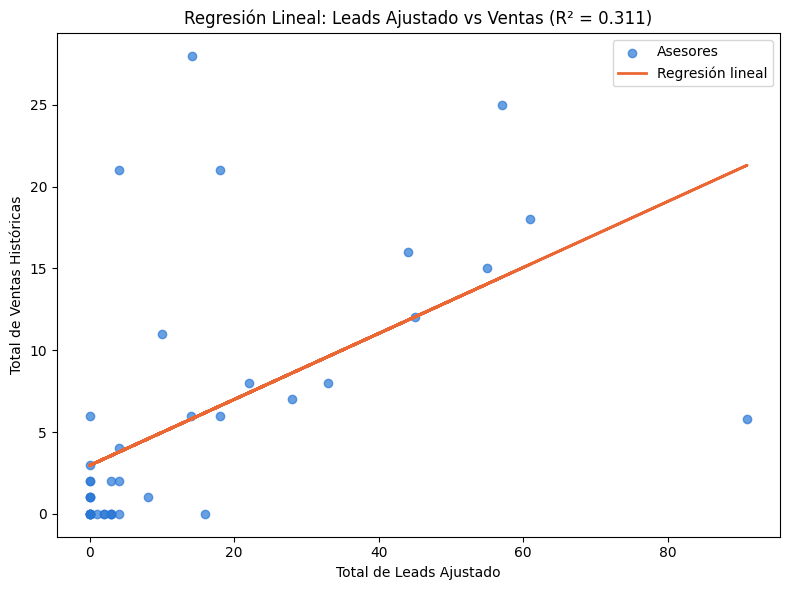

In [7]:
x = data_clean[['Total_Leads_Ajustado']].values
y = data_clean['Total_Ventas_Historicas'].values

modelo = LinearRegression().fit(x, y)
y_pred = modelo.predict(x)
r2 = r2_score(y, y_pred)

print(f"Ecuación: Ventas = {modelo.coef_[0]:.4f} * Leads_Ajustado + {modelo.intercept_:.4f}")
print(f"R\u00b2 = {r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='#2a78d6', alpha=0.7, label='Asesores')
plt.plot(x, y_pred, color='#eb6834', linewidth=2, label='Regresión lineal')
plt.xlabel('Total de Leads Ajustado')
plt.ylabel('Total de Ventas Históricas')
plt.title(f'Regresión Lineal: Leads Ajustado vs Ventas (R\u00b2 = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('regresion_piso.png', dpi=150)
plt.show()